# Switches Model: BRNS 2.0 vs. BRNS 3.0

This notebook compares toluene gas-phase profiles from the switches example using two data sources:

- BRNS 2.0 reference data from `paper/switches`
- BRNS 3.0 result data from `build/switches/results/python`

Only the files `tol_h_g_B3.inp` and `tol_d_g_B3.inp` are used.

## Comparison Quantities

For each dataset we define

$$
c = c_h + c_d, \quad R = \frac{c_h}{c_d},
$$

with reference values at the first grid point $c_0$ and $R_0$.

Right-panel transformed coordinates:

$$
x = \ln\left(\frac{c/c_0}{(R+1)/(R_0+1)}\right), \quad y = \ln\left(\frac{R}{R_0}\right).
$$

In [19]:
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

PAPER_REF_DIR = Path(os.environ.get('BRNS_SWITCHES_REF_DIR', 'paper/switches'))
RESULT_DIR = Path(os.environ.get('BRNS_SWITCHES_RESULT_DIR', 'build/switches/results/python'))
FIGURE_PATH = Path(os.environ.get('BRNS_SWITCHES_FIGURE', 'paper/switches_brns2_brns3_comparison.pdf'))
CONC_TO_MG_L = float(os.environ.get('BRNS_SWITCHES_CONC_TO_MG_L', '1.0'))

TOL_H_FILE = 'tol_h_g_B3.inp'
TOL_D_FILE = 'tol_d_g_B3.inp'

print('Reference directory:', PAPER_REF_DIR)
print('Result directory   :', RESULT_DIR)
print('Figure output      :', FIGURE_PATH)
print('Conc factor to mg/L:', CONC_TO_MG_L)

if not PAPER_REF_DIR.exists():
    raise FileNotFoundError(f'Reference directory not found: {PAPER_REF_DIR}')
if not RESULT_DIR.exists():
    raise FileNotFoundError(f'Result directory not found: {RESULT_DIR}')

Reference directory: paper/switches
Result directory   : build/switches/results/python
Figure output      : paper/switches_brns2_brns3_comparison.pdf
Conc factor to mg/L: 1.0


In [20]:
def load_profile(folder: Path, filename: str) -> tuple[np.ndarray, np.ndarray]:
    file_path = folder / filename
    if not file_path.exists():
        raise FileNotFoundError(f'Missing file: {file_path}')

    arr = np.loadtxt(file_path)
    if arr.ndim != 2 or arr.shape[1] < 2:
        raise ValueError(f'Unexpected file format in {file_path}: expected at least 2 columns')

    conc = np.asarray(arr[:, 0], dtype=float)
    x_cm = np.asarray(arr[:, 1], dtype=float)

    order = np.argsort(x_cm)
    return x_cm[order], conc[order]


def transformed_coordinates(c_h: np.ndarray, c_d: np.ndarray, eps: float = 1.0e-30) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    c_h = np.asarray(c_h, dtype=float)
    c_d = np.asarray(c_d, dtype=float)

    total = c_h + c_d
    R = c_d / np.maximum(c_h, eps)

    c0 = total[0]
    R0 = R[0]

    x_t = np.log((total / c0) / ((R + 1.0) / (R0 + 1.0)))
    y_t = np.log(R / R0)
    return total, R, x_t, y_t


x2_h, h2 = load_profile(PAPER_REF_DIR, TOL_H_FILE)
x2_d, d2 = load_profile(PAPER_REF_DIR, TOL_D_FILE)
x3_h, h3 = load_profile(RESULT_DIR, TOL_H_FILE)
x3_d, d3 = load_profile(RESULT_DIR, TOL_D_FILE)

if not (np.allclose(x2_h, x2_d) and np.allclose(x3_h, x3_d)):
    raise ValueError('Grid mismatch between tol_h and tol_d files')

total2, R2, xt2, yt2 = transformed_coordinates(h2, d2)
total3, R3, xt3, yt3 = transformed_coordinates(h3, d3)

total2_mg_l = total2 * CONC_TO_MG_L
total3_mg_l = total3 * CONC_TO_MG_L

print('Rows BRNS 2.0:', total2.shape[0])
print('Rows BRNS 3.0:', total3.shape[0])
print('x range BRNS 2.0 [cm]:', float(x2_h.min()), 'to', float(x2_h.max()))
print('x range BRNS 3.0 [cm]:', float(x3_h.min()), 'to', float(x3_h.max()))

Rows BRNS 2.0: 71
Rows BRNS 3.0: 71
x range BRNS 2.0 [cm]: 0.0 to 35.0
x range BRNS 3.0 [cm]: 0.0 to 35.0


In [21]:
def _align_on_reference_x(x_ref: np.ndarray, value_ref: np.ndarray, x_res: np.ndarray, value_res: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Interpolate result values to the reference x-grid for pointwise error comparison."""
    x_ref = np.asarray(x_ref, dtype=float)
    value_ref = np.asarray(value_ref, dtype=float)
    x_res = np.asarray(x_res, dtype=float)
    value_res = np.asarray(value_res, dtype=float)

    order_ref = np.argsort(x_ref)
    order_res = np.argsort(x_res)
    x_ref_s = x_ref[order_ref]
    value_ref_s = value_ref[order_ref]
    x_res_s = x_res[order_res]
    value_res_s = value_res[order_res]

    res_interp = np.interp(x_ref_s, x_res_s, value_res_s)
    return x_ref_s, value_ref_s, res_interp


def _error_stats(reference: np.ndarray, estimate: np.ndarray, rel_floor: float = 1.0e-20) -> dict[str, float | np.ndarray]:
    diff = np.asarray(estimate, dtype=float) - np.asarray(reference, dtype=float)
    abs_err = np.abs(diff)
    rel_err = abs_err / np.maximum(np.abs(reference), rel_floor)
    return {
        'abs_err': abs_err,
        'rel_err': rel_err,
        'mae': float(np.mean(abs_err)),
        'max_abs': float(np.max(abs_err)),
        'rmse': float(np.sqrt(np.mean(diff ** 2))),
        'mre': float(np.mean(rel_err)),
        'max_rel': float(np.max(rel_err)),
    }


# Left panel errors: total concentration over column length
x_total_cmp, total_ref_cmp, total_res_cmp = _align_on_reference_x(
    x2_h, total2_mg_l, x3_h, total3_mg_l
)
err_total = _error_stats(total_ref_cmp, total_res_cmp)

# Right panel errors: transformed-coordinate relation
x_trans_cmp, y_ref_cmp, y_res_cmp = _align_on_reference_x(
    xt2, yt2, xt3, yt3
)
err_transformed = _error_stats(y_ref_cmp, y_res_cmp)

print('Error summary (BRNS 3.0 vs BRNS 2.0 reference)')
print('=' * 116)
print(f"{'Quantity':<28} {'MAE':>14} {'Max |abs|':>14} {'RMSE':>14} {'Mean rel [%]':>16} {'Max rel [%]':>16}")
print('-' * 116)
print(f"{'Total toluene concentration':<28} {err_total['mae']:14.6e} {err_total['max_abs']:14.6e} {err_total['rmse']:14.6e} {100.0 * err_total['mre']:16.6e} {100.0 * err_total['max_rel']:16.6e}")
print(f"{'Transformed plot y(xt)':<28} {err_transformed['mae']:14.6e} {err_transformed['max_abs']:14.6e} {err_transformed['rmse']:14.6e} {100.0 * err_transformed['mre']:16.6e} {100.0 * err_transformed['max_rel']:16.6e}")

print('')
print('Pointwise arrays are available as:')
print("  err_total['abs_err'], err_total['rel_err']")
print("  err_transformed['abs_err'], err_transformed['rel_err']")

Error summary (BRNS 3.0 vs BRNS 2.0 reference)
Quantity                                MAE      Max |abs|           RMSE     Mean rel [%]      Max rel [%]
--------------------------------------------------------------------------------------------------------------------
Total toluene concentration    5.211267e-12   9.999998e-11   1.622899e-11     6.254850e-09     7.782017e-08
Transformed plot y(xt)         7.721459e-08   1.050796e-06   2.198321e-07     1.207652e-06     1.647222e-05

Pointwise arrays are available as:
  err_total['abs_err'], err_total['rel_err']
  err_transformed['abs_err'], err_transformed['rel_err']


Saved figure to paper/switches_brns2_brns3_comparison.pdf


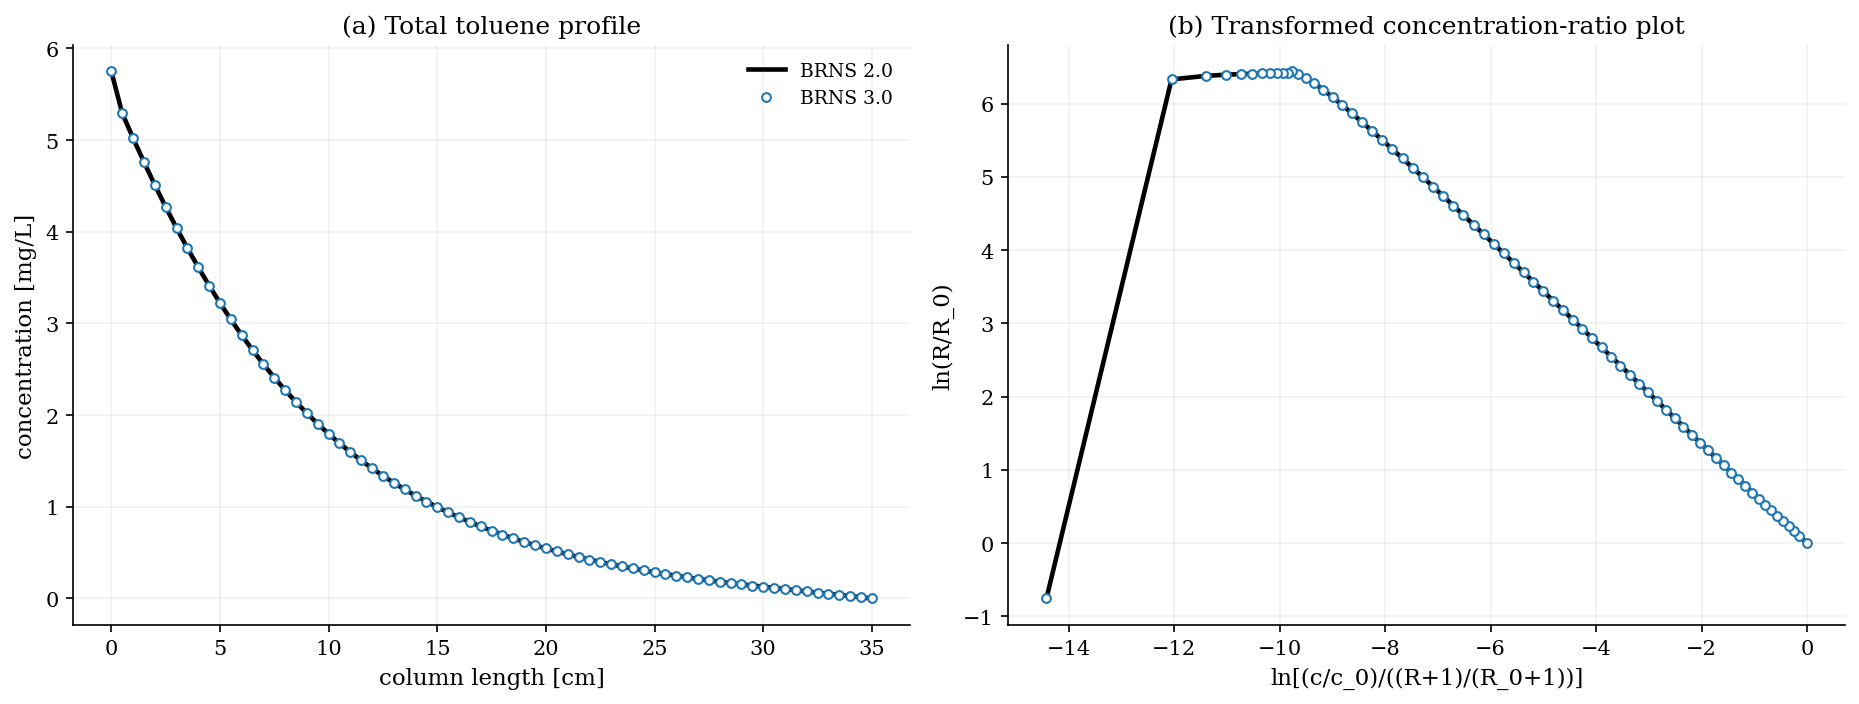

In [22]:
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'STIX Two Text', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
})

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))

# Left panel: total toluene concentration over column length
ax = axes[0]
ax.plot(x2_h, total2_mg_l, color='black', linewidth=2.2, label='BRNS 2.0')
ax.plot(x3_h, total3_mg_l, linestyle='none', marker='o', markersize=4.2, markerfacecolor='white', markeredgewidth=1.0, color='#1f77b4', label='BRNS 3.0')
ax.set_xlabel('column length [cm]')
ax.set_ylabel('concentration [mg/L]')
ax.set_title('(a) Total toluene profile')
ax.grid(True, which='major', alpha=0.18)
ax.legend(loc='best', frameon=False)

# Right panel: transformed coordinates
ax = axes[1]
ax.plot(xt2, yt2, color='black', linewidth=2.2, label='BRNS 2.0')
ax.plot(xt3, yt3, linestyle='none', marker='o', markersize=4.2, markerfacecolor='white', markeredgewidth=1.0, color='#1f77b4', label='BRNS 3.0')
ax.set_xlabel(r'ln[(c/c_0)/((R+1)/(R_0+1))]')
ax.set_ylabel(r'ln(R/R_0)')
ax.set_title('(b) Transformed concentration-ratio plot')
ax.grid(True, which='major', alpha=0.18)
#ax.legend(loc='best', frameon=False)

#fig.suptitle('Switches example: comparison of BRNS 2.0 reference and BRNS 3.0 output', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()

FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURE_PATH, bbox_inches='tight')
print('Saved figure to', FIGURE_PATH)
plt.show()